In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB



Missing values before handling:
Survived     0
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64
(418, 8)

After encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  34.5      0      0   7.8292         1
1         1       3    0  47.0      1      0   7.0000         2
2         0       2    1  62.0      0      0   9.6875         1
3         0       3    1  27.0      0      0   8.6625         2
4         1       3    0  22.0      1      1  12.2875         2

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

X:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  34.5      0      0   7.8292         1
1       3    0  47.0      1      0   7.0000         2
2       2    1  62.0      0      0   9.6875         1
3       3    1  27.0      0      0   8.6625    

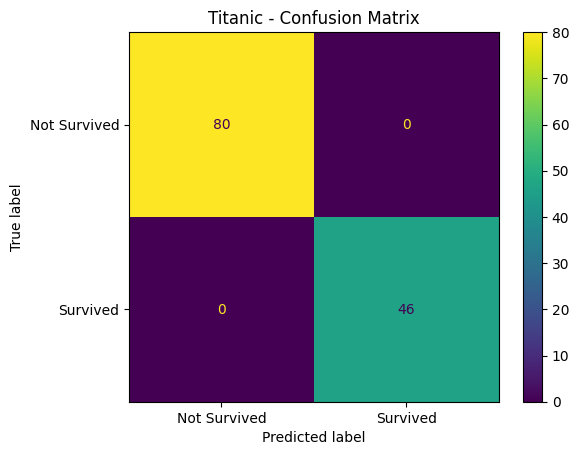


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        46

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



In [8]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt


df.drop(
    columns=["PassengerId", "Cabin", "Name", "Ticket"],
    inplace=True
)



print("\nMissing values before handling:")
print(df.isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Fare"] = df["Fare"].fillna(df["Fare"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df["Sex"] = le_sex.fit_transform(df["Sex"])
df["Embarked"] = le_embarked.fit_transform(df["Embarked"])

print(df.shape)

print("\nAfter encoding:")
print(df.head())

print("\nMissing values after handling:")
print(df.isnull().sum())

X = df.drop("Survived", axis=1)
y = df["Survived"]

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()

plt.title("Titanic - Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [1, 3, 5, 7, 9, 11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    print("K =", k, "Accuracy =", accuracy_score(y_test, y_pred))

K = 1 Accuracy = 0.9761904761904762
K = 3 Accuracy = 0.9682539682539683
K = 5 Accuracy = 0.9841269841269841
K = 7 Accuracy = 0.9841269841269841
K = 9 Accuracy = 0.9920634920634921
K = 11 Accuracy = 0.9920634920634921


In [10]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[80  0]
 [ 1 45]]


In [11]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        80
           1       1.00      0.98      0.99        46

    accuracy                           0.99       126
   macro avg       0.99      0.99      0.99       126
weighted avg       0.99      0.99      0.99       126



In [12]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
223,3,1,21.00,0,0,7.7958,2
150,1,0,23.00,0,1,83.1583,0
1,3,0,47.00,1,0,7.0000,2
54,2,1,27.00,0,0,15.5792,0
308,1,1,55.00,1,1,93.5000,2
...,...,...,...,...,...,...,...
58,3,1,27.00,1,0,16.1000,2
287,1,1,24.00,1,0,82.2667,2
307,3,1,0.83,0,1,9.3500,2
93,3,1,27.00,0,0,8.0500,2


In [13]:
X_train_scaled

array([[ 0.8214401 ,  0.75491223, -0.65935007, ..., -0.41760241,
        -0.47410971,  0.6572549 ],
       [-1.57716499, -1.32465731, -0.49615429, ...,  0.64274458,
         0.88023747, -1.75681342],
       [ 0.8214401 , -1.32465731,  1.46219505, ..., -0.41760241,
        -0.48841112,  0.6572549 ],
       ...,
       [ 0.8214401 ,  0.75491223, -2.3051795 , ...,  0.64274458,
        -0.44617903,  0.6572549 ],
       [ 0.8214401 ,  0.75491223, -0.16976273, ..., -0.41760241,
        -0.46954146,  0.6572549 ],
       [ 0.8214401 ,  0.75491223,  0.93180877, ..., -0.41760241,
        -0.34284519,  0.6572549 ]], shape=(292, 7))

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

#can use any scaled or unscaled any
model3 = GaussianNB()

model3.fit(X_train_scaled, y_train)

y_pred3 = model3.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred3))


1.0


In [15]:
confusion_matrix(y_test,y_pred3)

array([[80,  0],
       [ 0, 46]])

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model4 = DecisionTreeClassifier(max_depth=5,random_state=42)

model4.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred4))



Accuracy: 1.0


In [18]:
confusion_matrix(y_test,y_pred4)

array([[80,  0],
       [ 0, 46]])

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model5 = SVC(kernel="rbf")

model5.fit(X_train_scaled, y_train)


y_pred5 = model5.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred5))

Accuracy: 0.9841269841269841


In [23]:
confusion_matrix(y_test,y_pred5)

array([[79,  1],
       [ 1, 45]])